In [4]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

mpl.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman'],
    'font.size': 14,
    'axes.labelsize': 16,
    'axes.titlesize': 16,
    'xtick.labelsize': 12,
    'ytick.labelsize': 13,
    'legend.fontsize': 11,
    'axes.linewidth': 1.5,
    'xtick.major.width': 1.5,
    'ytick.major.width': 1.5,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'mathtext.fontset': 'stix',
})

models = ['Decision\nTree', 'Random\nForest', 'XGBoost', 'LightGBM', 'CatBoost',
          'SVM', 'Logistic\nRegression', 'AutoML-\nEnsemble', 'LAE-XAI-\nIDS']

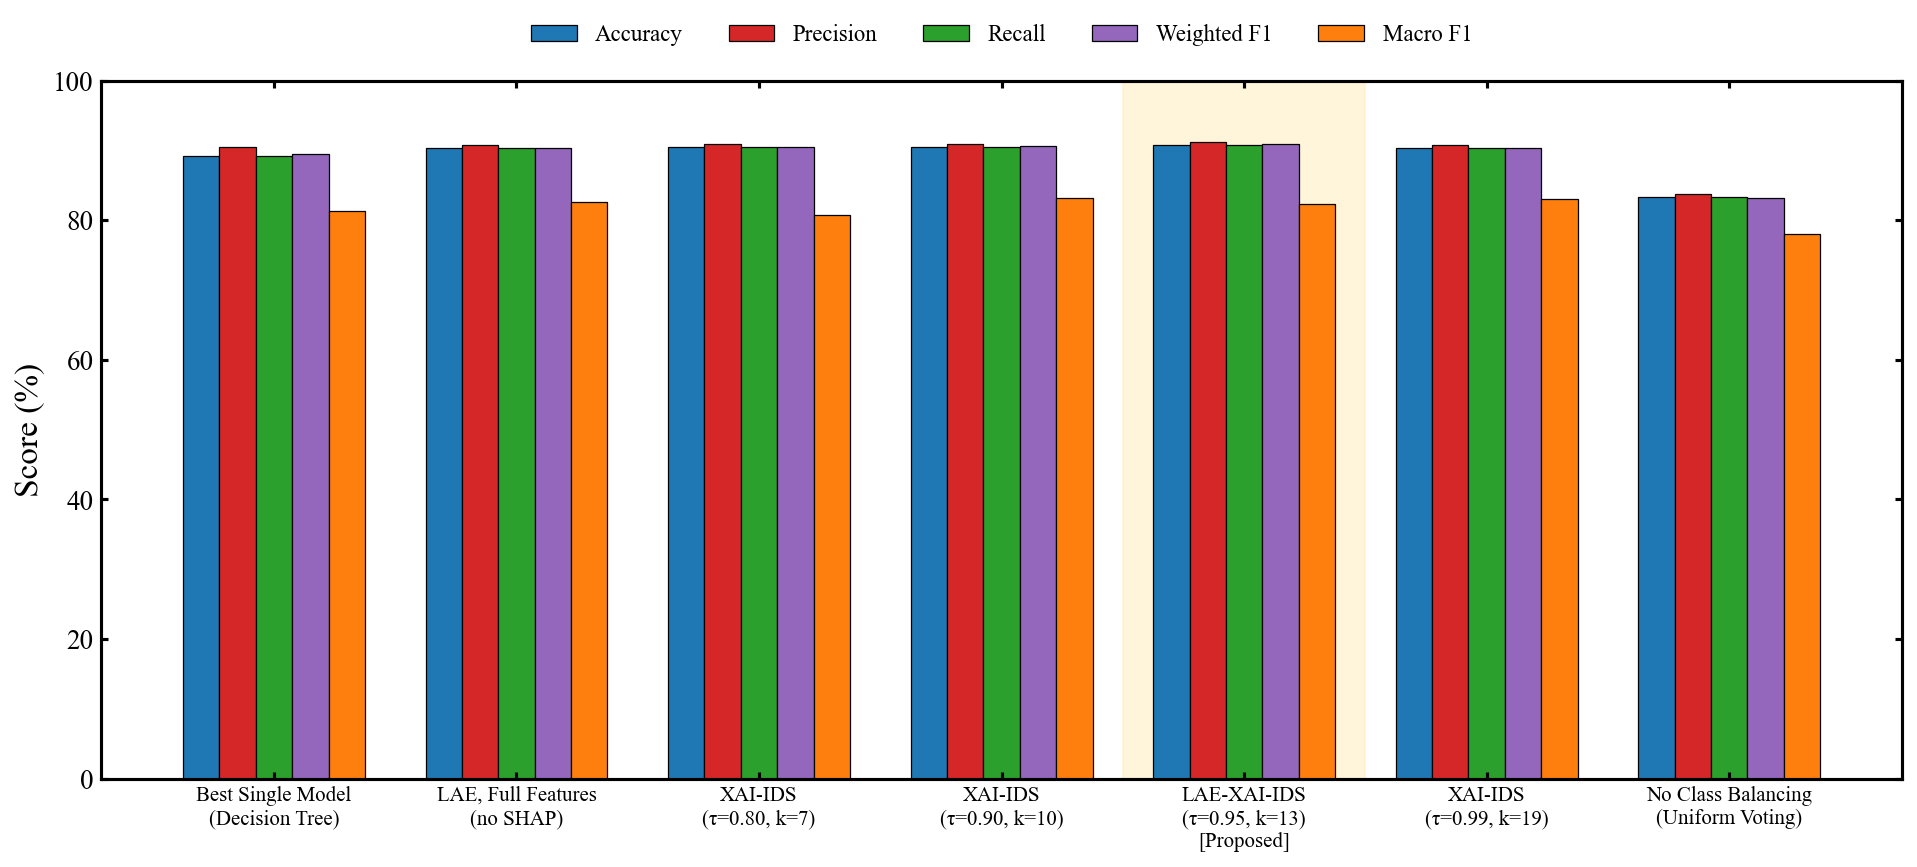

In [5]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

mpl.rcParams.update({
    'font.family': 'serif', 'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'font.size': 14, 'axes.labelsize': 16, 'axes.titlesize': 16,
    'xtick.labelsize': 10.5, 'ytick.labelsize': 13, 'legend.fontsize': 11,
    'axes.linewidth': 1.5, 'xtick.major.width': 1.5, 'ytick.major.width': 1.5,
    'xtick.direction': 'in', 'ytick.direction': 'in',
    'xtick.top': True, 'ytick.right': True,
    'figure.dpi': 150, 'savefig.dpi': 300, 'mathtext.fontset': 'stix',
})

variants = [
    'Best Single Model\n(Decision Tree)', 'LAE, Full Features\n(no SHAP)',
    'XAI-IDS\n(τ=0.80, k=7)', 'XAI-IDS\n(τ=0.90, k=10)',
    'LAE-XAI-IDS\n(τ=0.95, k=13)\n[Proposed]', 'XAI-IDS\n(τ=0.99, k=19)',
    'No Class Balancing\n(Uniform Voting)',
]

data = {
    'Accuracy':    [89.26265468, 90.30876973, 90.48130037, 90.55891184, 90.80249523, 90.31113816, 83.34796898],
    'Precision':   [90.50932881, 90.83621243, 90.9398511,  90.99100515, 91.2252092,  90.834635,   83.70204783],
    'Recall':      [89.26265468, 90.30876973, 90.48130037, 90.55891184, 90.80249523, 90.31113816, 83.34796898],
    'Weighted F1': [89.55065423, 90.41276266, 90.55620808, 90.62657416, 90.8747756,  90.41115556, 83.19129751],
    'Macro F1':    [81.2816256,  82.66188276, 80.79364862, 83.19868099, 82.31669338, 83.09583612, 78.02592826],
}
colors = ['#1f77b4', '#d62728', '#2ca02c', '#9467bd', '#ff7f0e']

fig, ax = plt.subplots(figsize=(13, 6))
x = np.arange(len(variants))
bar_width = 0.15
n = len(data)

for i, (metric, values) in enumerate(data.items()):
    offset = (i - (n - 1) / 2) * bar_width
    ax.bar(x + offset, values, width=bar_width, label=metric,
           color=colors[i], edgecolor='black', linewidth=0.6)

proposed_idx = 4
ax.axvspan(proposed_idx - 0.5, proposed_idx + 0.5, color='#ffefc2', zorder=0, alpha=0.6)

ax.set_xticks(x); ax.set_xticklabels(variants, fontsize=10)
ax.set_ylabel('Score (%)'); ax.set_ylim(0, 100)
ax.tick_params(which='both', direction='in', top=True, right=True)
for spine in ax.spines.values(): spine.set_linewidth(1.5)
ax.legend(loc='lower center', bbox_to_anchor=(0.5, 1.02), ncol=5, frameon=False)

plt.tight_layout()
plt.savefig('ablation_fig1_performance.png', bbox_inches='tight')
plt.show()

AttributeError: module 'matplotlib.pyplot' has no attribute 'sh'

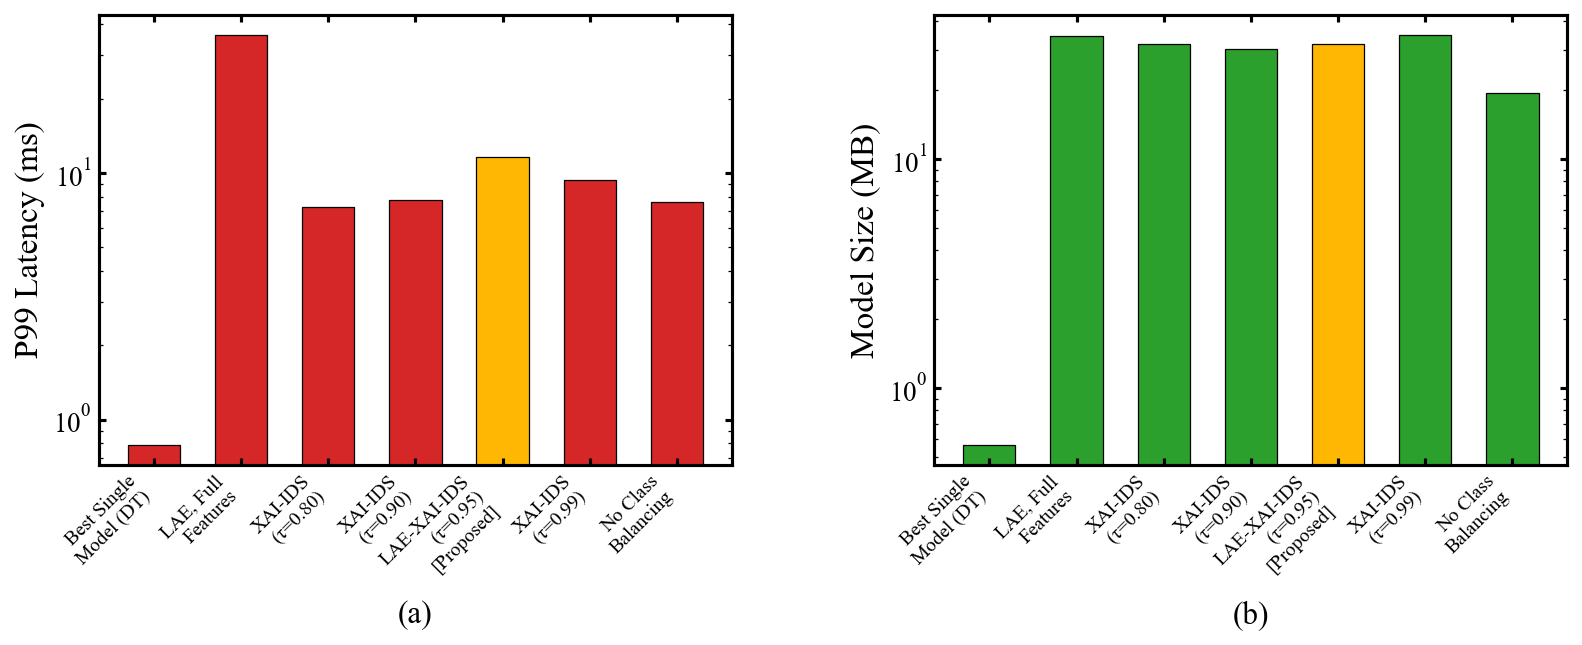

In [8]:
variants2 = ['Best Single\nModel (DT)', 'LAE, Full\nFeatures', 'XAI-IDS\n(τ=0.80)',
             'XAI-IDS\n(τ=0.90)', 'LAE-XAI-IDS\n(τ=0.95)\n[Proposed]',
             'XAI-IDS\n(τ=0.99)', 'No Class\nBalancing']

p99_latency = [0.792203978, 36.108574, 7.245368978, 7.766571034, 11.59248304, 9.385636044, 7.620670989]
model_size  = [0.566697121, 34.56803036, 31.73860645, 30.26812172, 31.74630547, 34.70714664, 19.46961784]

fig, axes = plt.subplots(1, 2, figsize=(11, 6))
x = np.arange(len(variants2))
proposed_idx = 4
panel_data = [('P99 Latency (ms)', p99_latency, '#d62728'),
              ('Model Size (MB)', model_size, '#2ca02c')]

for ax, (ylabel, values, color) in zip(axes, panel_data):
    bar_colors = ['#ffb703' if i == proposed_idx else color for i in range(len(variants2))]
    ax.bar(x, values, color=bar_colors, edgecolor='black', linewidth=0.6, width=0.6)
    ax.set_yscale('log')
    ax.set_xticks(x); ax.set_xticklabels(variants2, rotation=45, ha='right', fontsize=9.5)
    ax.set_ylabel(ylabel)
    ax.tick_params(which='both', direction='in', top=True, right=True)
    for spine in ax.spines.values(): spine.set_linewidth(1.5)

for ax, lab in zip(axes, ['(a)', '(b)']):
    ax.text(0.5, -0.30, lab, transform=ax.transAxes, ha='center', va='top',
            fontsize=15)

plt.subplots_adjust(top=0.88, bottom=0.38, left=0.09, right=0.98, wspace=0.32)
plt.savefig('ablation_fig2_efficiency.png', pad_inches=0.2)
plt.sh